In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
import matplotlib.pyplot as plt
import sqlite3

In [ ]:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from matplotlib import pyplot

In [ ]:
data = pd.read_csv('data.csv')

In [ ]:
data

,TAU (nM),IR (Gy),status
0,0.0,5,1
1,2.0,5,1
2,4.0,5,1
3,6.0,5,1
4,8.0,5,1
5,10.0,5,1
6,12.0,5,1
7,14.0,5,1
8,16.0,5,1
9,18.0,5,1


In [ ]:
x1 = data.iloc[:,[0]].values
x1

array([[ 0.],
       [ 2.],
       [ 4.],
       [ 6.],
       [ 8.],
       [10.],
       [12.],
       [14.],
       [16.],
       [18.],
       [20.],
       [22.],
       [24.],
       [26.],
       [28.],
       [30.],
       [32.],
       [34.],
       [36.],
       [38.],
       [40.],
       [42.],
       [44.],
       [46.],
       [48.],
       [50.]])

In [ ]:
x2 = data.iloc[:,[1]].values
x2

array([[5],
       [5],
       [5],
       [5],
       [5],
       [5],
       [5],
       [5],
       [5],
       [5],
       [5],
       [5],
       [5],
       [5],
       [5],
       [5],
       [5],
       [5],
       [5],
       [5],
       [5],
       [5],
       [5],
       [5],
       [5],
       [5]])

In [ ]:
y=data.iloc[:,2].values
y

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0])

In [ ]:
x_train = data[["TAU (nM)", "IR (Gy)"]]
x_train

,TAU (nM),IR (Gy)
0,0.0,5
1,2.0,5
2,4.0,5
3,6.0,5
4,8.0,5
5,10.0,5
6,12.0,5
7,14.0,5
8,16.0,5
9,18.0,5


In [ ]:
X2_train, X2_test,y_train,y_test = train_test_split(x_train,y,test_size=0.2,random_state=0)

In [ ]:
X2_train

,TAU (nM),IR (Gy)
22,44.0,5
13,26.0,5
18,36.0,5
19,38.0,5
16,32.0,5
1,2.0,5
10,20.0,5
25,50.0,5
24,48.0,5
8,16.0,5


In [ ]:
y_pred = logreg.predict(X2_test)
y_pred

array([1, 0, 0, 0, 1, 1])

In [ ]:
print('Accuracy of logistic regression classifier on train set: {}'.format(logreg.score(X2_test, y_test)))

Accuracy of logistic regression classifier on train set: 0.8333333333333334


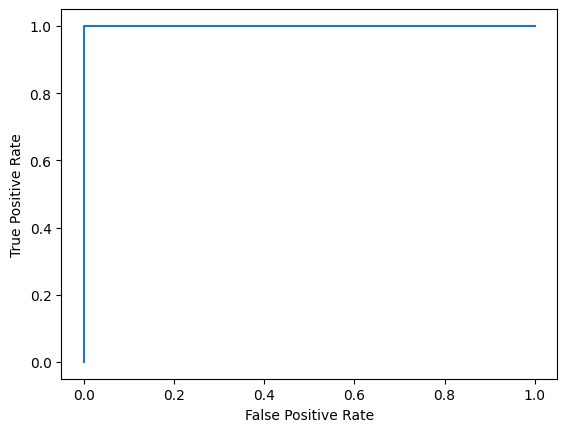

In [ ]:
y_pred_proba = logreg.predict_proba(X2_test)[::,1]
fpr, tpr, _ = metrics.roc_curve(y_test,  y_pred_proba)

#create ROC curve
plt.plot(fpr,tpr)
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

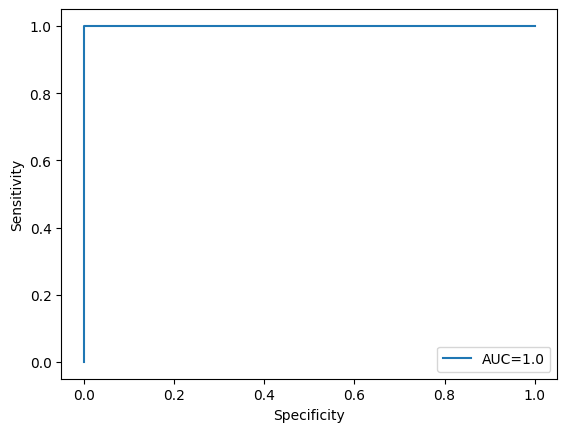

In [ ]:
#define metrics
y_pred_proba = logreg.predict_proba(X2_test)[::,1]
fpr, tpr, _ = metrics.roc_curve(y_test,  y_pred_proba)
auc = metrics.roc_auc_score(y_test, y_pred_proba)

#create ROC curve
plt.plot(fpr,tpr,label="AUC="+str(auc))
plt.ylabel('Sensitivity')
plt.xlabel('Specificity')
plt.legend(loc=4)
plt.show()

In [ ]:
lr_probs = logreg.predict_proba(X2_train)
# keep probabilities for the positive outcome only
lr_probs = lr_probs[:, 1]
lr_probs


array([0.37476664, 0.48297356, 0.42198595, 0.41000978, 0.44620193,
       0.62795499, 0.51993052, 0.340803  , 0.35196362, 0.54447265,
       0.56880067, 0.59280111, 0.53222107, 0.55667064, 0.3632883 ,
       0.60464467, 0.63939805, 0.38638757, 0.45841386, 0.49529182])

In [ ]:

# calculate scores
ns_probs = [1 for _ in range(len(y_test))]
ns_probs

[1, 1, 1, 1, 1, 1]

In [ ]:
pred_prob1 = logreg.predict_proba(X2_train)
fpr1, tpr1, thresh1 = roc_curve(y_train, pred_prob1[:,1], pos_label=1)

# # roc curve for tpr = fpr
random_probs = [0 for i in range(len(y_test))]
p_fpr, p_tpr, _ = roc_curve(y_test, random_probs, pos_label=1)

np.sum(pred_prob1)

20.0

In [ ]:
thresh1

array([1.63939805, 0.63939805, 0.45841386, 0.340803  ])

In [ ]:
db = sqlite3.connect('record.db')

In [ ]:
# Create a table to store book information
db.execute('''CREATE TABLE IF NOT EXISTS patient
                 (id INTEGER PRIMARY KEY AUTOINCREMENT,
                  name TEXT NOT NULL,
                  status INTEGER NOT NULL,
                  value INTEGER NOT NULL,
                  radiation INTEGER NOT NULL)''')

In [ ]:
name = input("Enter the name: ")
status = int(input("Enter the status: "))
value = input("Enter the value: ")
radiation = input("Enter the radiation: ")

Enter the name: Manas
Enter the status: 0
Enter the value: 500
Enter the radiation: 50


In [ ]:
# Insert the book information into the database
db.execute("INSERT INTO patient (name, status, value, radiation) VALUES (?, ?, ?, ?)", (name, status, value, radiation))
x = db.execute('''SELECT * FROM patient''').fetchall()
print(x)
db.commit()


[(1, 'Manas', 1, 50, 20), (2, 'Manas', 0, 500, 50), (3, 'Manas', 0, 500, 50), (4, 'Manas', 0, 500, 50)]
